In [119]:
import pandas as pd
import matplotlib.pyplot as plt

from v2_preparation import process_modis, process_landsat, process_modis_nbar, slice_by_dates
from v2_features_processing import merge_datasets

In [120]:
study_site = 'SDH3'
start_date = '2000'
end_date = '2026'

if study_site == 'SDH1':
    target = 'SDH1PS01_gw-depth_m'
    modis_filepath = '../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv'
    nbar_filepath = '../data/processed/satellites/SDH1_MNBAR_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv'

elif study_site == 'SDH2':
    target = 'SDH2PP01_gw-depth_m'
    modis_filepath = '../data/processed/satellites/SDH2_MT_500m_2000-03_2026-06.csv'
    nbar_filepath = '../data/processed/satellites/SDH2_MNBAR_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH2_L_30m_1984-07_2026-06.csv'

elif study_site == 'SDH3':
    modis_filepath = '../data/processed/satellites/SDH3_MT_500m_2000-03_2026-06.csv'
    nbar_filepath = '../data/processed/satellites/SDH3_MNBAR_500m_2000-03_2026-06.csv'

else:
    print(f'{study_site} not supported as study site')

band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

modis_cols = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
landsat_cols = ['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean']

In [121]:
modis_df = process_modis(
    filepath=modis_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=modis_cols,
    outlier_threshold=3.0,
    smooth_window=31
)

nbar_df = process_modis_nbar(
    filepath=nbar_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=modis_cols,
    outlier_threshold=3.0
)

sr_df = process_modis_nbar(
    filepath=modis_filepath,
    start_date=start_date,
    end_date=end_date,
    cols_to_keep=modis_cols,
    outlier_threshold=3.0
)

In [122]:
merged_daily = modis_df.join(nbar_df, how='left', lsuffix='_sr', rsuffix='_nbar')
merged_inner = modis_df.join(nbar_df, how='inner', lsuffix='_sr', rsuffix='_nbar').dropna()

In [123]:
start = '2004'
end= start
nbar_sliced = slice_by_dates(nbar_df, start, end)
nbar_sliced.isna().sum()

blue     11
green    17
red      17
nir      16
swir1    39
swir2    11
dtype: int64

In [124]:
def plot_modis_vs_nbar_series(
    modis_df,
    nbar_df,
    sr_df,
    target_bands,
    start_date=None,
    end_date=None,
    figure_size=(14, 5)
):
    """
    Plot continuous smoothed MODIS time series with overlaid valid NBAR observations.
    """
    # Filter both DataFrames by the defined temporal window
    filtered_modis = slice_by_dates(modis_df, start_date, end_date)
    filtered_nbar = slice_by_dates(nbar_df, start_date, end_date)
    filtered_sr = slice_by_dates(sr_df, start_date, end_date)

    # Ensure target_bands is a list for iteration
    if isinstance(target_bands, str):
        target_bands = [target_bands]

    # Create subplots for each requested band
    total_bands = len(target_bands)
    fig, axes = plt.subplots(
        nrows=total_bands, 
        ncols=1, 
        figsize=(figure_size[0], figure_size[1] * total_bands),
        sharex=True
    )

    # Standardize axes to iterable array when only one band is plotted
    if total_bands == 1:
        axes = [axes]

    for current_axis, band_name in zip(axes, target_bands):
        # Extract valid non-null NBAR observations for the current band
        valid_nbar = filtered_nbar.dropna(subset=[band_name])
        valid_sr = filtered_sr.dropna(subset=[band_name])

        # Plot continuous MODIS line (interpolated and smoothed)
        current_axis.plot(
            filtered_modis.index,
            filtered_modis[band_name],
            color='royalblue',
            linewidth=1,
            label='MOD09GA (Savitzky-Golay)'
        )

        # Overlay discrete NBAR points
        current_axis.scatter(
            valid_nbar.index,
            valid_nbar[band_name],
            color='firebrick',
            s=10,
            alpha=0.85,
            edgecolors='none',
            label='MCD43A4 (NBAR)'
        )

        # Plot original MOD09GA
        current_axis.plot(
            valid_sr.index,
            valid_sr[band_name],
            color='orange',
            linewidth=1,
            label='MOD09GA (original)'
        )

        # Configure axis presentation
        current_axis.set_title(f'Band Comparison: {band_name.upper()}', fontsize=12, fontweight='bold')
        current_axis.set_ylabel('Surface Reflectance', fontsize=10)
        current_axis.grid(True, linestyle='--', alpha=0.5)
        current_axis.legend(loc='upper right', frameon=True)

    # Configure shared x-axis label
    axes[-1].set_xlabel('Date', fontsize=10)
    plt.tight_layout()
    plt.show()

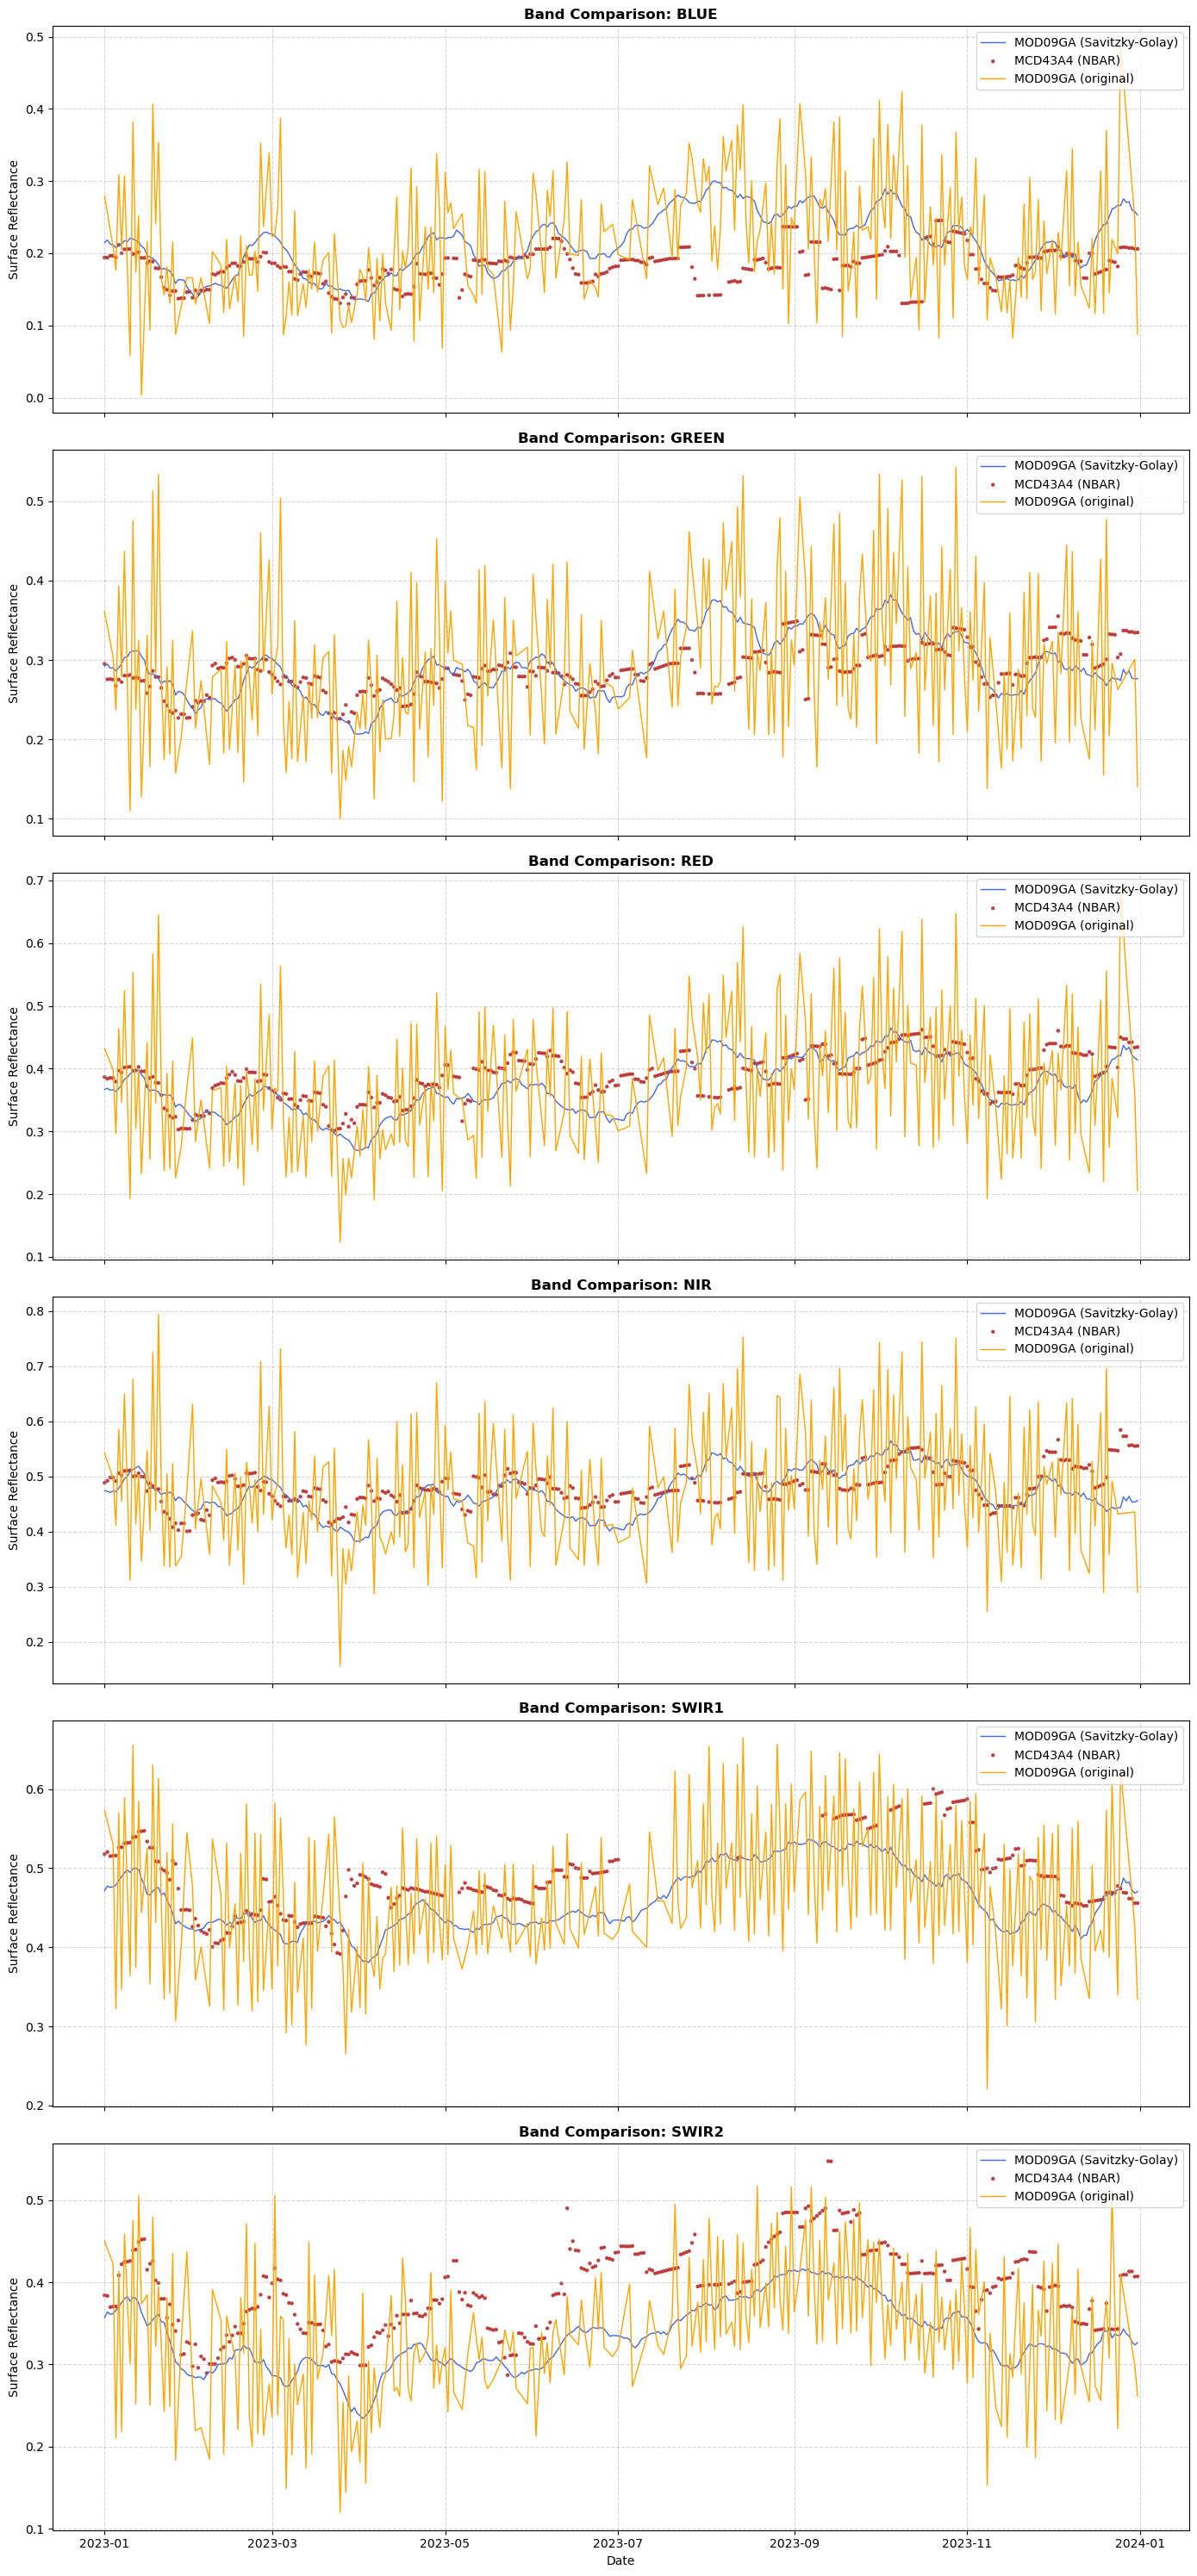

In [125]:
plot_modis_vs_nbar_series(modis_df, nbar_df, sr_df, modis_cols, '2023', '2023')